In [1]:
# ── Global paths ──────────────────────────────────────────────────────────────
SWEAT_0 = "../20260404-experiment/sweat.csv"   # Defective — NH3 pin disconnected (miswired from start)
SWEAT_1 = "../20260405-experiment/sweat.csv"   # Reference — clean wiring
SWEAT_2 = "../20260331-experiment/sweat.csv"
BLOOD_0 = "../20260406-experiment/1.5_blood.csv"
BLOOD_1 = "../20260406-experiment/1.5_blood_2.csv"

SPEC     = ["h2s_ppm", "etoh_ppm"]
ENV      = ["temp_C", "rh_pct"]
CHANNELS = SPEC + ENV

EMA_SPAN = 30   # default EMA span in samples (≈ seconds at 1 Hz)


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

def load(path, t_min=1500, t_max=None):
    df = pd.read_csv(path, parse_dates=["wall_time"])
    df["elapsed_s"] = (df["wall_time"] - df["wall_time"].iloc[0]).dt.total_seconds()
    for col in CHANNELS:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df[df["elapsed_s"] >= t_min]
    if t_max is not None:
        df = df[df["elapsed_s"] < t_max]
    return df.reset_index(drop=True)

sweat_0  = load(SWEAT_0, t_max=4000)
sweat_1  = load(SWEAT_1)                                 # full — for initial visualization
sweat_1a = load(SWEAT_1, t_max=3900)                     # first sweat sample
sweat_1b = load(SWEAT_1, t_min=3900)                     # second sweat sample
sweat_1b = sweat_1b.assign(                              # reset elapsed to start from 0
    elapsed_s=sweat_1b["elapsed_s"] - sweat_1b["elapsed_s"].iloc[0]
)
sweat_1b = sweat_1b[sweat_1b["elapsed_s"] >= 200].reset_index(drop=True)  # trim stabilization
sweat_2  = load(SWEAT_2)
blood_0  = load(BLOOD_0)
blood_1  = load(BLOOD_1, t_min=1750)                     # trim stabilization

print({
    "sweat_0":  len(sweat_0),
    "sweat_1":  len(sweat_1),
    "sweat_1a": len(sweat_1a),
    "sweat_1b": len(sweat_1b),
    "sweat_2":  len(sweat_2),
    "blood_0":  len(blood_0),
    "blood_1":  len(blood_1),
})


{'sweat_0': 2412, 'sweat_1': 4833, 'sweat_1a': 2345, 'sweat_1b': 2292, 'sweat_2': 4108, 'blood_0': 2201, 'blood_1': 1908}


## Initial Visualization

Raw signal for SPEC sensors (H2S ppm, EtOH ppm) and environmental sensors (Temp °C, Humidity % RH).
SWEAT_0 excluded (defective). SWEAT_2 excluded for now.


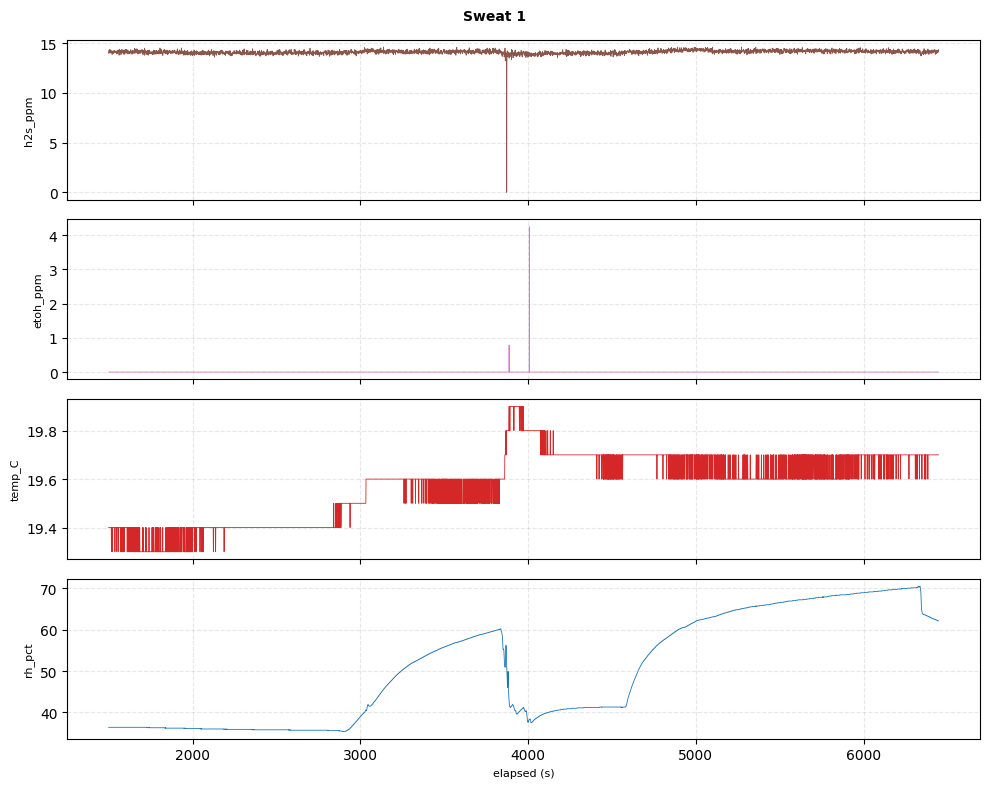

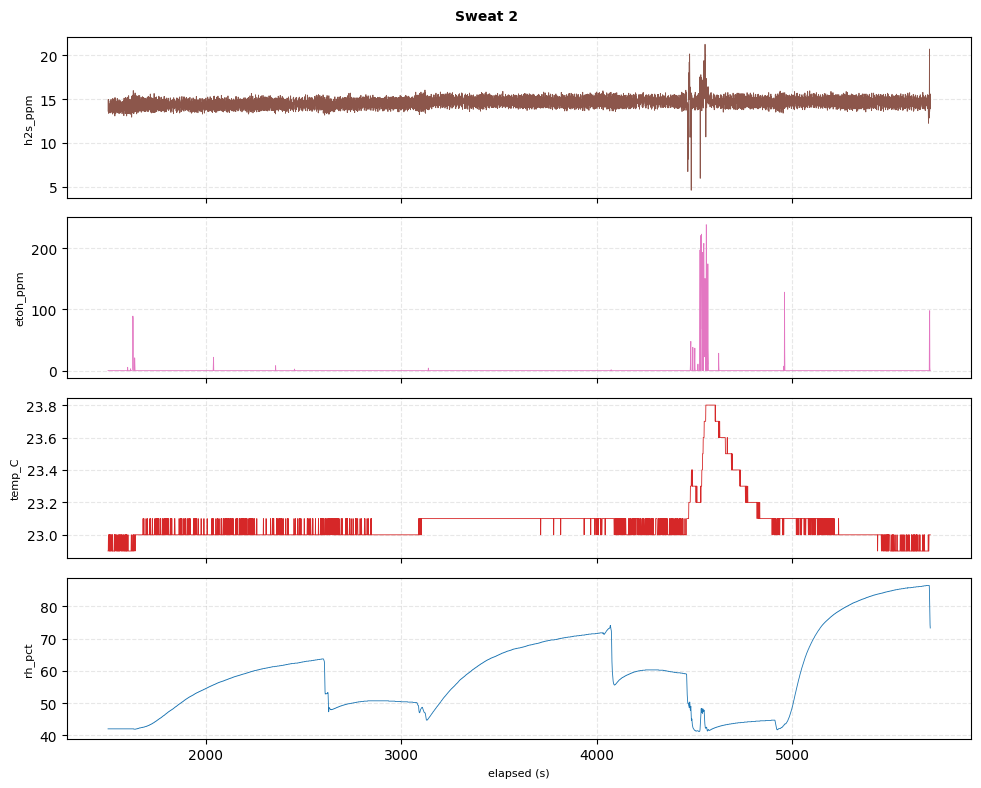

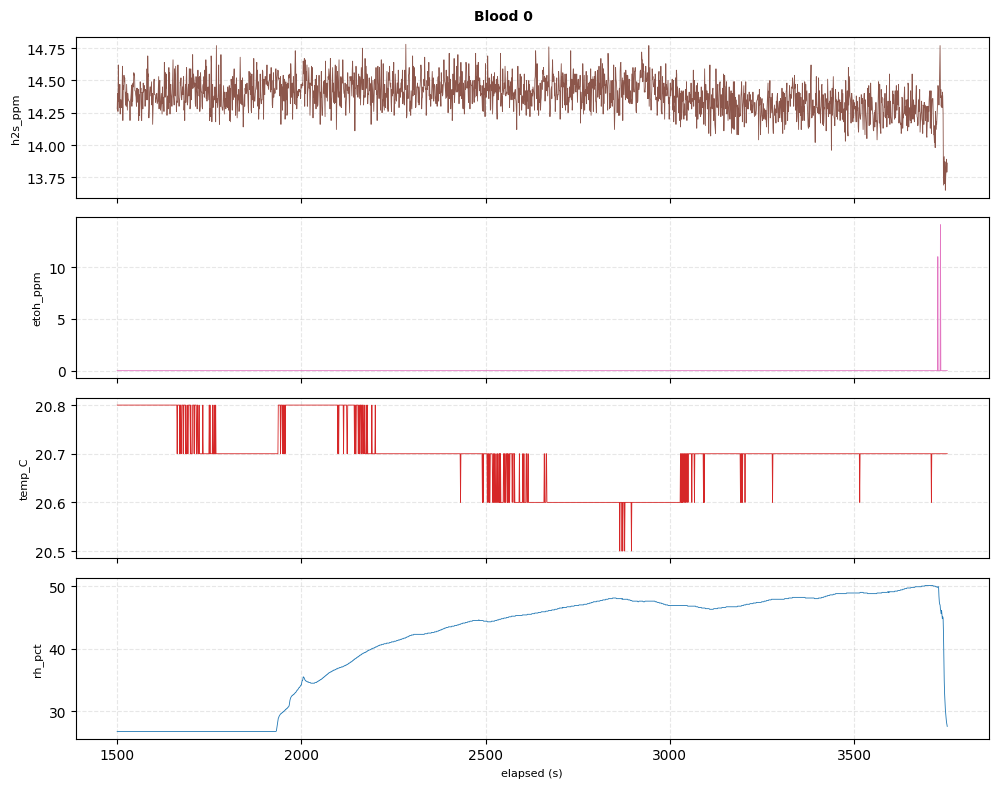

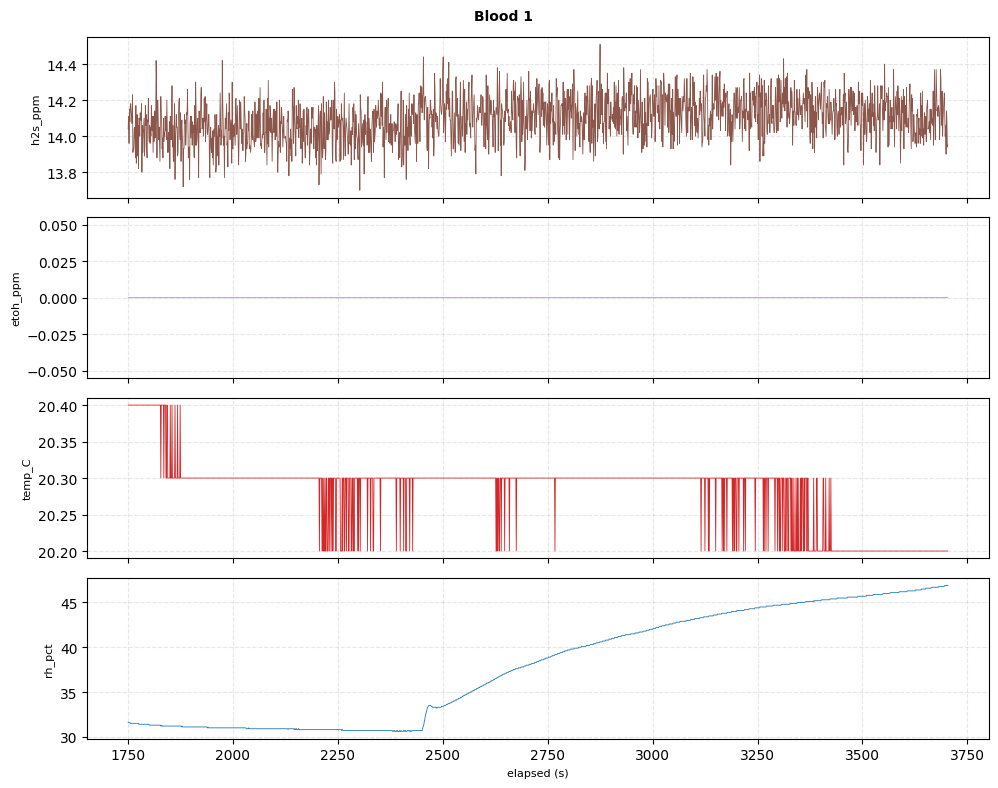

In [3]:
COLORS = {
    "h2s_ppm":  "tab:brown",
    "etoh_ppm": "tab:pink",
    "temp_C":   "tab:red",
    "rh_pct":   "tab:blue",
}

datasets = {
    "Sweat 1": sweat_1,
    "Sweat 2": sweat_2,
    "Blood 0": blood_0,
    "Blood 1": blood_1,
}

def plot_raw(name, df):
    fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
    fig.suptitle(name, fontsize=10, fontweight="bold")
    for ax, col in zip(axes, CHANNELS):
        ax.plot(df["elapsed_s"], df[col], color=COLORS[col], linewidth=0.6)
        ax.set_ylabel(col, fontsize=8)
        ax.grid(True, alpha=0.3, linestyle="--")
    axes[-1].set_xlabel("elapsed (s)", fontsize=8)
    plt.tight_layout()
    plt.show()

for name, df in datasets.items():
    plot_raw(name, df)


## Filtered Visualization

Datasets in scope: **SWEAT_1a, SWEAT_1b, BLOOD_0, BLOOD_1**. SWEAT_0 and SWEAT_2 excluded for now.

All channels use a **causal EMA filter** (real-time compatible — no future data used).

| Dataset | Trimming | H2S | EtOH | Temp | Humidity |
|---------|----------|-----|------|------|----------|
| SWEAT_1a | 1500s – 3900s | EMA span=30 | EMA span=30 | EMA span=30 | EMA span=30 |
| SWEAT_1b | 3900s+ (reset), discard first 200s | EMA span=30 | EMA span=30 | EMA span=30 | EMA span=30 |
| BLOOD_0 | 1500s+ | EMA span=30 | EMA span=30 | EMA span=30 | EMA span=30 |
| BLOOD_1 | 1750s+ | EMA span=30 | EMA span=30 | EMA span=30 | EMA span=30 |


In [ ]:
# ── Per-dataset filter config ─────────────────────────────────────────────────
# span: default EMA span (samples ≈ seconds at 1 Hz)
# span_override: {col: span} — per-channel span override
# artifact_windows: {col: [(t_start, t_end), ...]} — regions to patch via linear interp

FILTER_CONFIG = {
    "SWEAT_1a": {
        "span": 30,
        "span_override": {},
        "artifact_windows": {},
    },
    "SWEAT_1b": {
        "span": 30,
        "span_override": {},
        "artifact_windows": {},
    },
    "BLOOD_0": {
        "span": 30,
        "span_override": {},
        "artifact_windows": {},
    },
    "BLOOD_1": {
        "span": 30,
        "span_override": {},
        "artifact_windows": {},
    },
}

# ── Filter application ────────────────────────────────────────────────────────
def apply_filter(df, config):
    out = df.copy()
    for col in CHANNELS:
        s = out[col].copy().astype(float)

        # Patch artifact windows via linear interpolation
        for t0, t1 in config.get("artifact_windows", {}).get(col, []):
            mask = (out["elapsed_s"] >= t0) & (out["elapsed_s"] <= t1)
            s[mask] = float("nan")
            s = s.interpolate(method="linear").ffill().bfill()

        # Causal EMA — per-channel span override if specified
        span = config.get("span_override", {}).get(col, config["span"])
        out[col] = s.ewm(span=span, adjust=False).mean()

    return out

filtered = {
    name: apply_filter(df, FILTER_CONFIG[name])
    for name, df in [
        ("SWEAT_1a", sweat_1a),
        ("SWEAT_1b", sweat_1b),
        ("BLOOD_0",  blood_0),
        ("BLOOD_1",  blood_1),
    ]
}


In [ ]:
raw_map = {
    "SWEAT_1a": sweat_1a,
    "SWEAT_1b": sweat_1b,
    "BLOOD_0":  blood_0,
    "BLOOD_1":  blood_1,
}

for name, filt_df in filtered.items():
    raw_df = raw_map[name]
    fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
    fig.suptitle(f"{name} — Raw vs Filtered", fontsize=10, fontweight="bold")

    for ax, col in zip(axes, CHANNELS):
        color = COLORS[col]
        ax.plot(raw_df["elapsed_s"],  raw_df[col],  color=color, linewidth=0.5, alpha=0.4, label="Raw")
        ax.plot(filt_df["elapsed_s"], filt_df[col], color=color, linewidth=1.4, label="EMA filtered")
        ax.set_ylabel(col, fontsize=8)
        ax.legend(fontsize=7, loc="upper left")
        ax.grid(True, alpha=0.3, linestyle="--")

    axes[-1].set_xlabel("elapsed (s)", fontsize=8)
    plt.tight_layout()
    plt.show()
